In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('Citizen_Eligibility_Data_Final.csv')
df


,Citizen_ID,Age,Gender,Annual_Income,Employment_Status,Family_Size,Education_Level,Social_Category,Disability,Rural_Urban,Scheme_Eligibility
0,1,56.0,Female,913204.0,Employed,1,Secondary,General,No,Rural,0
1,2,69.0,Female,596312.0,Employed,3,Graduate,General,No,Rural,1
2,3,46.0,Female,817768.0,Self-employed,10,Graduate,SC,No,Urban,0
3,4,32.0,Female,657200.0,Unemployed,4,Primary,OBC,No,Urban,0
4,5,60.0,Female,829521.0,Employed,4,Graduate,OBC,No,Rural,0
...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,18.0,Male,722010.0,Employed,4,Graduate,SC,No,Urban,1
4996,4997,32.0,Female,469230.0,Self-employed,7,Secondary,OBC,No,Rural,0
4997,4998,54.0,Male,650709.0,Employed,6,Graduate,General,No,Rural,0
4998,4999,30.0,Male,319578.0,Unemployed,9,Graduate,SC,No,Urban,1


In [38]:
df.columns.values

array(['Citizen_ID', 'Age', 'Gender', 'Annual_Income',
       'Employment_Status', 'Family_Size', 'Education_Level',
       'Social_Category', 'Disability', 'Rural_Urban',
       'Scheme_Eligibility'], dtype=object)

In [39]:
df.shape

(5000, 11)

In [40]:
df.dtypes

Citizen_ID              int64
Age                   float64
Gender                 object
Annual_Income         float64
Employment_Status      object
Family_Size             int64
Education_Level        object
Social_Category        object
Disability             object
Rural_Urban            object
Scheme_Eligibility      int64
dtype: object

In [41]:
df.head()

,Citizen_ID,Age,Gender,Annual_Income,Employment_Status,Family_Size,Education_Level,Social_Category,Disability,Rural_Urban,Scheme_Eligibility
0,1,56.0,Female,913204.0,Employed,1,Secondary,General,No,Rural,0
1,2,69.0,Female,596312.0,Employed,3,Graduate,General,No,Rural,1
2,3,46.0,Female,817768.0,Self-employed,10,Graduate,SC,No,Urban,0
3,4,32.0,Female,657200.0,Unemployed,4,Primary,OBC,No,Urban,0
4,5,60.0,Female,829521.0,Employed,4,Graduate,OBC,No,Rural,0


In [42]:
df4=df['Family_Size'].value_counts()   
df4

Family_Size
6     528
4     528
2     521
1     514
3     499
7     499
10    491
9     488
8     473
5     459
Name: count, dtype: int64

In [43]:
df.tail()

,Citizen_ID,Age,Gender,Annual_Income,Employment_Status,Family_Size,Education_Level,Social_Category,Disability,Rural_Urban,Scheme_Eligibility
4995,4996,18.0,Male,722010.0,Employed,4,Graduate,SC,No,Urban,1
4996,4997,32.0,Female,469230.0,Self-employed,7,Secondary,OBC,No,Rural,0
4997,4998,54.0,Male,650709.0,Employed,6,Graduate,General,No,Rural,0
4998,4999,30.0,Male,319578.0,Unemployed,9,Graduate,SC,No,Urban,1
4999,5000,57.0,Female,866460.0,Employed,2,Secondary,General,NaN,Rural,1


In [44]:
df3=df['Education_Level'].value_counts()   
df3

Education_Level
Graduate        2120
Secondary       1550
Postgraduate     754
Primary          456
Name: count, dtype: int64

In [45]:
df1=df['Gender'].value_counts()   
df1

Gender
Female    2436
Male      2385
Other      179
Name: count, dtype: int64

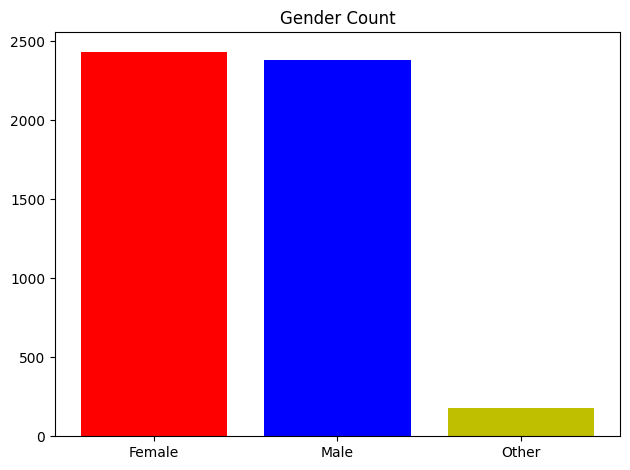

In [46]:
plt.bar(df1.index,df1.values,color=['r','b','y'])
plt.title('Gender Count')
plt.tight_layout()

In [47]:
df2=df['Scheme_Eligibility'].value_counts()   
df2

Scheme_Eligibility
0    2727
1    2273
Name: count, dtype: int64

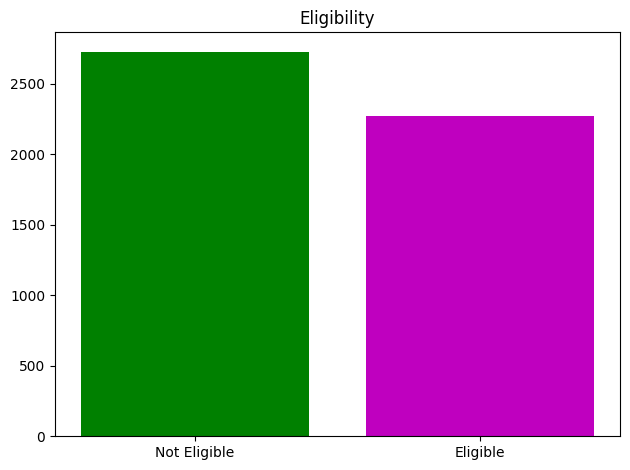

In [48]:
plt.bar(df2.index,df2.values,color=['g','m'])
plt.xticks([0,1],['Not Eligible','Eligible'])
plt.title('Eligibility')
plt.tight_layout()

<function matplotlib.pyplot.show(close=None, block=None)>

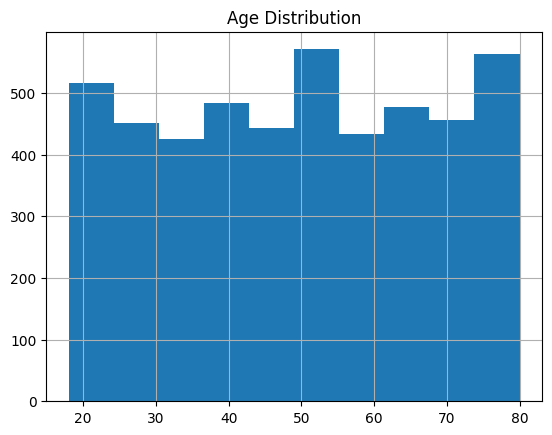

In [49]:
df['Age'].hist()
plt.title("Age Distribution")
plt.show

In [50]:
df.isna().sum()

Citizen_ID              0
Age                   177
Gender                  0
Annual_Income         240
Employment_Status      95
Family_Size             0
Education_Level       120
Social_Category         0
Disability            687
Rural_Urban             0
Scheme_Eligibility      0
dtype: int64

In [51]:
df["Age"].fillna(df["Age"].median().astype(int), inplace=True)
df["Annual_Income"].fillna(df["Annual_Income"].median(), inplace=True)
df["Education_Level"].fillna(df["Education_Level"].mode()[0], inplace=True)
df["Employment_Status"].fillna(df["Employment_Status"].mode()[0], inplace=True)
df["Disability"].fillna(df["Disability"].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_4488\4067600482.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median().astype(int), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_4488\4067600482.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [52]:
df.isna().sum()

Citizen_ID            0
Age                   0
Gender                0
Annual_Income         0
Employment_Status     0
Family_Size           0
Education_Level       0
Social_Category       0
Disability            0
Rural_Urban           0
Scheme_Eligibility    0
dtype: int64

In [53]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

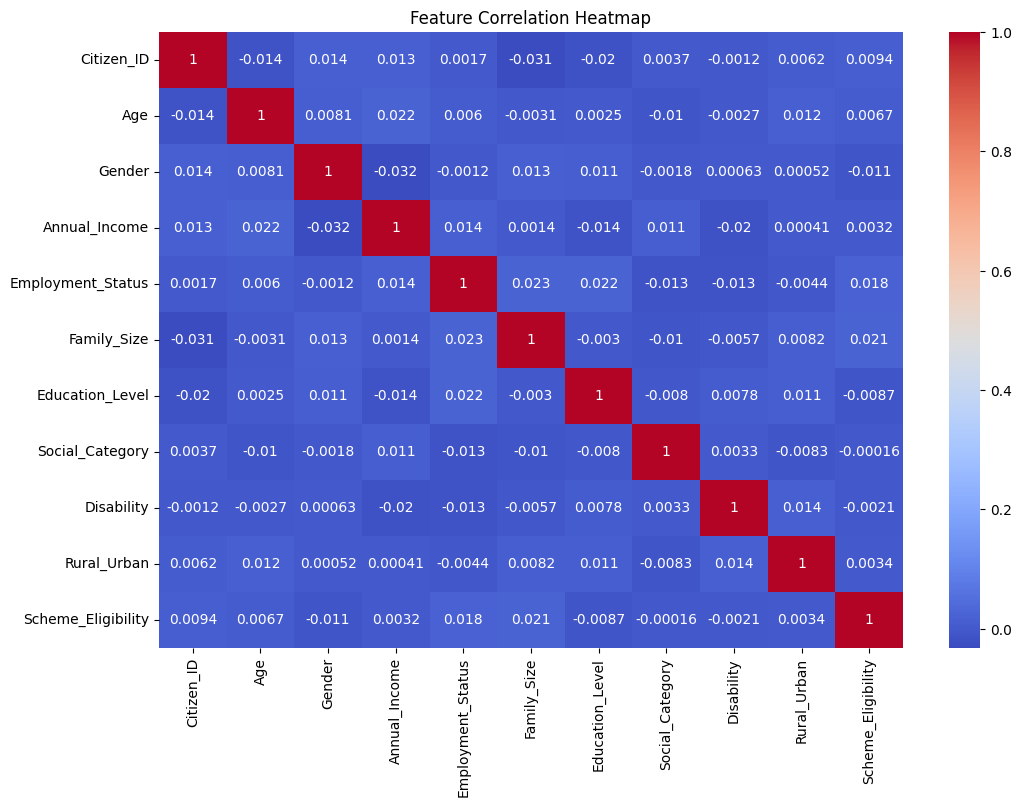

In [54]:
plt.figure(figsize=(12,8))
corr = df.corr()  # correlation of all numeric columns
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

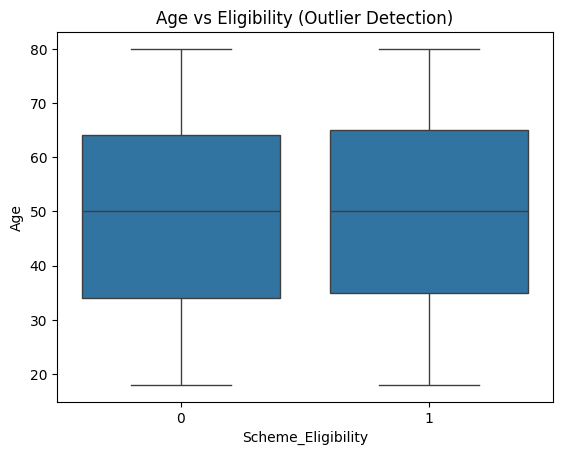

In [55]:
sns.boxplot(x="Scheme_Eligibility", y="Age", data=df)
plt.title("Age vs Eligibility (Outlier Detection)")
plt.show()


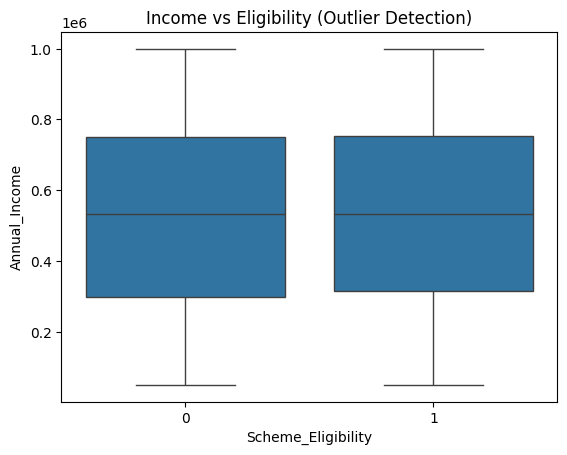

In [56]:
sns.boxplot(x="Scheme_Eligibility", y="Annual_Income", data=df)
plt.title("Income vs Eligibility (Outlier Detection)")
plt.show()

In [57]:
df.head()

,Citizen_ID,Age,Gender,Annual_Income,Employment_Status,Family_Size,Education_Level,Social_Category,Disability,Rural_Urban,Scheme_Eligibility
0,1,56.0,0,913204.0,0,1,3,0,0,0,0
1,2,69.0,0,596312.0,0,3,0,0,0,0,1
2,3,46.0,0,817768.0,1,10,0,2,0,1,0
3,4,32.0,0,657200.0,2,4,2,1,0,1,0
4,5,60.0,0,829521.0,0,4,0,1,0,0,0


In [58]:
df.drop(['Citizen_ID'],axis=1,inplace=True)

In [59]:
# Drop ID & target & unwanted categorical column
x = df.drop("Scheme_Eligibility", axis=1)
y = df["Scheme_Eligibility"]

In [60]:
x.columns

Index(['Age', 'Gender', 'Annual_Income', 'Employment_Status', 'Family_Size',
       'Education_Level', 'Social_Category', 'Disability', 'Rural_Urban'],
      dtype='object')

In [61]:

from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [62]:
x_test.columns

Index(['Age', 'Gender', 'Annual_Income', 'Employment_Status', 'Family_Size',
       'Education_Level', 'Social_Category', 'Disability', 'Rural_Urban'],
      dtype='object')

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
model_random=RandomForestClassifier(n_estimators=100)
model_random.fit(x_train,y_train)
y_pred_random=model_random.predict(x_test)
y_pred_random

array([0, 1, 0, ..., 1, 0, 0], shape=(1500,))

In [64]:
random_score=model_random.score(x,y)
random_score

0.8622

In [65]:
import joblib
joblib.dump(model_random,"eligibility_model.pkl")

['eligibility_model.pkl']

In [66]:
model_random.feature_names_in_

array(['Age', 'Gender', 'Annual_Income', 'Employment_Status',
       'Family_Size', 'Education_Level', 'Social_Category', 'Disability',
       'Rural_Urban'], dtype=object)

In [67]:
df["Scheme_Eligibility"].value_counts(normalize=True)

Scheme_Eligibility
0    0.5454
1    0.4546
Name: proportion, dtype: float64

In [94]:
test_input=pd.DataFrame([{
    "Age":28,
    "Gender":0,
    "Annual_Income":40000,
    "Employment_Status":0,
    "Family_Size":6,
    "Education_Level":0,
    "Social_Category":0,
    "Disability":0,
    "Rural_Urban":0
}])
model_random.predict(test_input)

array([0])

In [92]:
test_input=pd.DataFrame([{
    "Age":25,
    "Gender":0,
    "Annual_Income":900000,
    "Employment_Status":2,
    "Family_Size":2,
    "Education_Level":3,
    "Social_Category":3,
    "Disability":0,
    "Rural_Urban":1
}])
model_random.predict(test_input)

array([1])

In [70]:
model_random.predict_proba(test_input)

array([[0.46, 0.54]])